# TP N°1 Regresión Lineal y Polinómica
* Dado el conjunto de datos, plantear una regresión lineal (grado 1) y analizar si ese modelo es el óptimo para los datos dados.
* Luego plantear una regresión polinómica (defina el grado del polinomio que mejor se adpate a los datos)
* Realice para todos los casos, el grafi simultáneo de los datos y el modelo generado.
* Analizar resultados.  

## 1. Conjunto de Datos


In [1]:
import numpy as np #Librería numérica
import matplotlib.pyplot as plt # Para crear gráficos con matplotlib
%matplotlib inline
# Si quieres hacer estos gráficos dentro de un jupyter notebook
from sklearn.linear_model import LinearRegression #Regresión Lineal con scikit-learn

creamos el conjunto de datos, usando f(x)

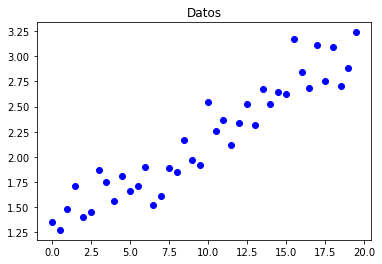

In [2]:
def f(x):  # función f(x) = 0.1*x + 1.25 + 0.2*Ruido_Gaussiano
    np.random.seed(42) # para poder reproducirlo
    y = 0.1*x + 1.25 + 0.2*np.random.randn(x.shape[0])
    return y

x = np.arange(0, 20, 0.5) # generamos valores x de 0 a 20 en intervalos de 0.5
y = f(x) # calculamos y a partir de la función que hemos generado

# hacemos un gráfico de los datos que hemos generado
plt.scatter(x,y,label='data', color='blue')
plt.title('Datos');

Dimensiones de los conjuntos x e y

In [3]:
print(f"Dimension eje y {y.shape}, tipo de dato: {type(y.shape)}")
print(y)
print(f"Dimension eje x {x.shape}, tipo de dato: {type(x.shape)}")
print(x)


Dimension eje y (40,), tipo de dato: <class 'tuple'>
[1.34934283 1.27234714 1.47953771 1.70460597 1.40316933 1.45317261
 1.86584256 1.75348695 1.55610512 1.80851201 1.65731646 1.70685405
 1.89839245 1.51734395 1.60501643 1.88754249 1.84743378 2.16284947
 1.96839518 1.91753926 2.54312975 2.25484474 2.36350564 2.11505036
 2.34112346 2.52218452 2.31980128 2.6751396  2.52987226 2.64166125
 2.62965868 3.17045564 2.84730056 2.68845781 3.11450898 2.75583127
 3.09177272 2.70806598 2.88436279 3.23937225]
Dimension eje x (40,), tipo de dato: <class 'tuple'>
[ 0.   0.5  1.   1.5  2.   2.5  3.   3.5  4.   4.5  5.   5.5  6.   6.5
  7.   7.5  8.   8.5  9.   9.5 10.  10.5 11.  11.5 12.  12.5 13.  13.5
 14.  14.5 15.  15.5 16.  16.5 17.  17.5 18.  18.5 19.  19.5]


## 2. Regresión Lineal
Importamos la clase de Regresión Lineal de scikit-learn y entrenamos el modelo con los datos.

In [4]:
from sklearn.linear_model import LinearRegression

regresion_lineal = LinearRegression()

x = x.reshape(-1,1)

regresion_lineal.fit(x,y)


(40, 1)

In [13]:
# Predecimos los valores y para los datos usados en el entrenamiento
w, b = regresion_lineal.coef_[0], regresion_lineal.intercept_

y_pred_entrenamiento = regresion_lineal.predict(x)

## Función predictora
El resultado es obtener la función para predecir, dado valores 

In [14]:
print("predicciones del modelo")
print(y_pred_entrenamiento)
print('------------------\nfunción del modelo\n------------------')
print ('f(x)= ',w,"x", "+" ,b)

predicciones del modelo
[1.28587925 1.33179686 1.37771447 1.42363208 1.46954969 1.5154673
 1.56138491 1.60730252 1.65322013 1.69913774 1.74505534 1.79097295
 1.83689056 1.88280817 1.92872578 1.97464339 2.020561   2.06647861
 2.11239622 2.15831383 2.20423144 2.25014905 2.29606666 2.34198426
 2.38790187 2.43381948 2.47973709 2.5256547  2.57157231 2.61748992
 2.66340753 2.70932514 2.75524275 2.80116036 2.84707797 2.89299558
 2.93891318 2.98483079 3.0307484  3.07666601]
------------------
función del modelo
------------------


AttributeError: 'numpy.ndarray' object has no attribute 'coef_'

## Calculamos el Error Cuadrático Medio
MSE = Mean Squared Error

Es una medida estadística que se utiliza para evaluar qué tan bien un modelo predice o ajusta los datos. Es muy común en problemas de regresión y aprendizaje automático.
La fórmula del **Error Cuadrático Medio** es:
$$
ECM = \sqrt{ \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 }
$$
Donde:


- \( y_i \): valor real  
- \( \hat{y}_i \): valor predicho  
- \( n \): número total de observaciones


In [7]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_true = y, y_pred = y_pred_entrenamiento)
# La raíz cuadrada del MSE es el RMSE
rmse = np.sqrt(mse)
print('Error Cuadrático Medio (MSE) = ' + str(mse))
print('Raíz del Error Cuadrático Medio (RMSE) = ' + str(rmse))

Error Cuadrático Medio (MSE) = 0.03318522012927899
Raíz del Error Cuadrático Medio (RMSE) = 0.18216810952875093


In [9]:
# calculamos el coeficiente de determinación R2
r2 = regresion_lineal.score(x, y)
print('Coeficiente de Determinación R2 = ' + str(r2))

Coeficiente de Determinación R2 = 0.8943593637683117


Tengo 3 valores de error el MSE, el RMSE y el R2, con valores distintos, pero como ¿para una función de error el modelo es mejor que para otra función de error?  

Indicar el valor de los parámetros calculados para el modelo.

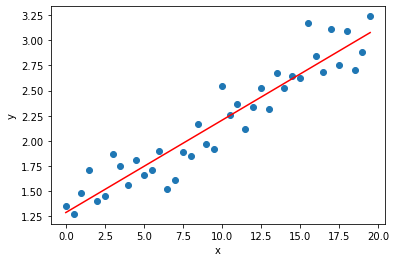

In [10]:
plt.scatter(x,y)
prediccion = regresion_lineal.predict(x.reshape(-1,1))
plt.plot(x,prediccion,'r')
plt.xlabel('x')
plt.ylabel('y')
plt.show()